# Bank Churn Intelligence - Notebook 02: Exploratory Data Analysis

## Objective
Visually investigate why customers are leaving
analysis covering geography, products, complaints, age, balance, card type and engagement - each with a business insight.

In [28]:
import pandas as pd
import numpy as nmp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

#Load Data
df = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Churned: {df['Exited'].sum():,} | Retained: {(df['Exited']==0).sum():,}")

Loaded: 10,000 rows x 18 columns
Churned: 2,038 | Retained: 7,962


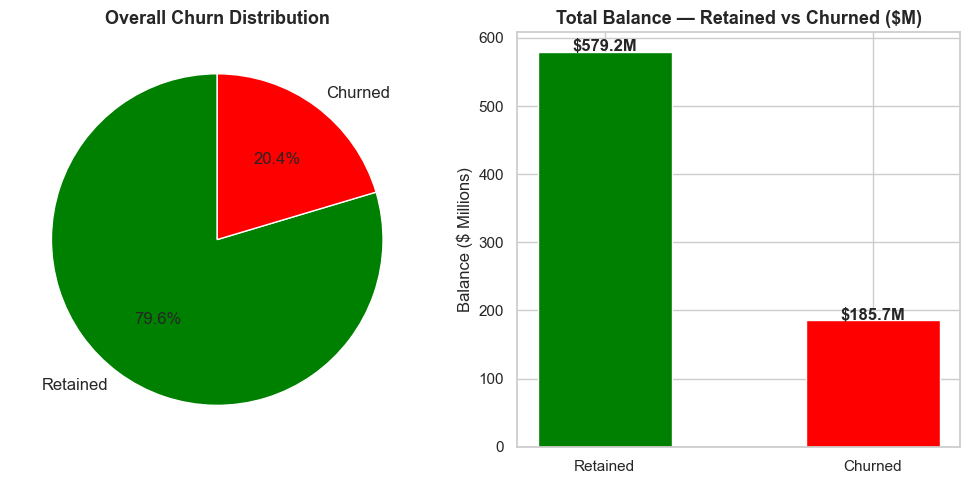

Chart saved to dashboard folder


In [29]:
# Analysis 1 - Overall Churn Rate 
fig, axes = plt.subplots(1,2, figsize=(10,5))

#Pie Chart
churn_counts = df['Exited'].value_counts()
colors = ['Green', 'Red']
axes[0].pie(churn_counts, labels=['Retained','Churned'],
autopct='%1.1f%%', colors=colors, startangle=90,
textprops={'fontsize':12})
axes[0].set_title('Overall Churn Distribution')

# Balance lost vs retained
balance_summary = df.groupby('Exited')['Balance'].sum() / 1e6
bars = axes[1].bar(['Retained', 'Churned'], balance_summary.values,
                    color=['Green', 'Red'], width=0.5)
axes[1].set_title('Total Balance — Retained vs Churned ($M)')
axes[1].set_ylabel('Balance ($ Millions)')
for bar, val in zip(bars, balance_summary.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/01_overall_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to dashboard folder")

### Analysis 1 — Business Insight

**Finding:** 20.4% of customers churned — 1 in every 5 customers left the bank.

**Revenue impact:** $185M in customer deposits walked out the door.

**What the bank should do:** This is not a minor retention problem.
Losing $185M in deposits affects the bank's lending capacity and liquidity.
This needs board-level attention, not just a marketing campaign.

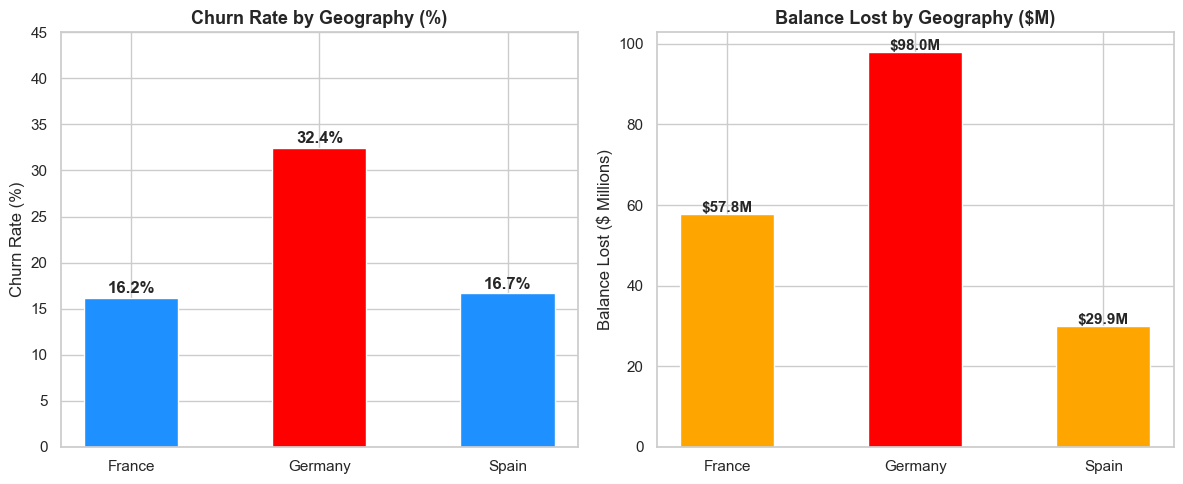

Chart saved.


In [30]:
# ANALYSIS 2: Geography — which country is the biggest problem?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
colors_geo = ['red' if v == geo_churn.max() else 'dodgerblue' 
              for v in geo_churn.values]
bars = axes[0].bar(geo_churn.index, geo_churn.values, color=colors_geo, width=0.5)
axes[0].set_title('Churn Rate by Geography (%)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 45)
for bar, val in zip(bars, geo_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Balance lost by geography
geo_balance = df[df['Exited']==1].groupby('Geography')['Balance'].sum() / 1e6
colors_bal = ['red' if v == geo_balance.max() else 'orange' 
              for v in geo_balance.values]
bars2 = axes[1].bar(geo_balance.index, geo_balance.values, color=colors_bal, width=0.5)
axes[1].set_title('Balance Lost by Geography ($M)')
axes[1].set_ylabel('Balance Lost ($ Millions)')
for bar, val in zip(bars2, geo_balance.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}M', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../dashboard/02_geography_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 2 — Business Insight

**Finding:** Germany churns at ~32% — more than double France's rate (~16%).
Despite being only 25% of the customer base, Germany contributes
the largest share of balance lost.

**What the bank should do:** Germany is not a churn problem —
it is a country-specific crisis. Possible causes: a local competitor
offering better rates, a product that doesn't fit German market needs,
or a service quality gap in that region.

**Recommended action:** Conduct exit interviews specifically for
Germany customers. This needs a geo-targeted retention strategy,
not a blanket campaign.

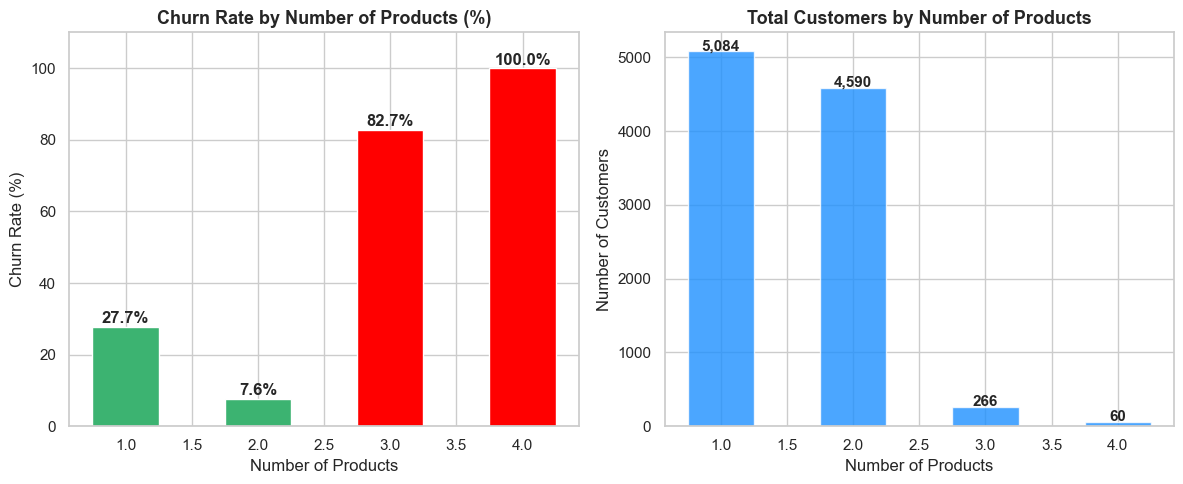

Chart saved.


In [31]:
# ANALYSIS 3: Number of products — the counter-intuitive finding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by number of products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
colors_prod = ['mediumseagreen' if v < 50 else 'red' for v in prod_churn.values]
bars = axes[0].bar(prod_churn.index, prod_churn.values, color=colors_prod, width=0.5)
axes[0].set_title('Churn Rate by Number of Products (%)')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, prod_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Customer count by products — to show scale
prod_count = df.groupby('NumOfProducts')['Exited'].count()
axes[1].bar(prod_count.index, prod_count.values, 
            color='dodgerblue', width=0.5, alpha=0.8)
axes[1].set_title('Total Customers by Number of Products')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(axes[1].patches, prod_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../dashboard/03_products_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 3 — Business Insight

**Finding:** Customers with 3 or 4 products churn at 82–100%.
This is the most counter-intuitive finding in the dataset.

Common assumption: more products = more loyalty.
Reality: more products = more friction = faster exit.

**What the bank should do:** Stop cross-selling beyond 2 products
per customer without a relationship review first. Customers with 3+
products should be flagged for an immediate RM check-in call.
The bank is accidentally accelerating churn by selling more.